# Loan Default Prediction - EDA & Baseline Models
Dataset: Lending Club Loan Data (396k rows, 27 features)

Goal: Predict loan default using classification models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('lending_club_loan_two.csv')
df=data.copy()
df.shape

(396030, 27)

In [3]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

## Exploratory Data Analysis

In [5]:
df['loan_status'].value_counts()

,count
loan_status,
Fully Paid,318357
Charged Off,77673


In [6]:
df.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,396030.000000,396030.000000,396030.000000,3.960300e+05,396030.000000,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,358235.000000,395495.000000
mean,14113.888089,13.639400,431.849698,7.420318e+04,17.379514,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648
std,8357.441341,4.472157,250.727790,6.163762e+04,18.019092,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174
min,500.000000,5.320000,16.080000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.330000,4.500000e+04,11.280000,8.000000,0.000000,6.025000e+03,35.800000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.430000,6.400000e+04,16.910000,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000
75%,20000.000000,16.490000,567.300000,9.000000e+04,22.980000,14.000000,0.000000,1.962000e+04,72.900000,32.000000,3.000000,0.000000
max,40000.000000,30.990000,1533.810000,8.706582e+06,9999.000000,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000


In [7]:
df['default']=df['loan_status'].apply(
    lambda x  : 1 if x in ['Charged Off'] else 0
)
print(f"Default rate: {df['default'].mean():.2%}")

Default rate: 19.61%


In [8]:
df['default'].value_counts()

,count
default,
0,318357
1,77673


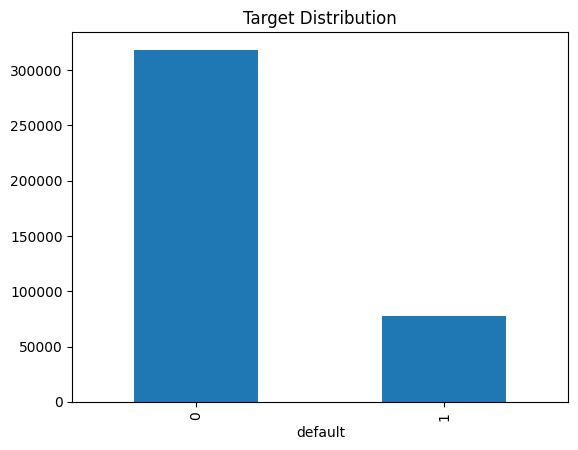

In [9]:
df['default'].value_counts().plot(kind='bar')
plt.title('Target Distribution')
plt.show()

## Data Cleaning & Preprocessing

In [10]:
drop_cols = ['loan_status', 'id', 'member_id', 'url', 'desc',
             'title', 'zip_code', 'addr_state', 'issue_d',
             'earliest_cr_line', 'last_pymnt_d', 'next_pymnt_d',
             'last_credit_pull_d', 'pymnt_plan']

df = df.drop([col for col in drop_cols if col in df.columns], axis=1)

In [11]:
df.isnull().sum().sort_values(ascending=False)

,0
mort_acc,37795
emp_title,22927
emp_length,18301
pub_rec_bankruptcies,535
revol_util,276
installment,0
loan_amnt,0
term,0
grade,0
sub_grade,0


In [12]:
df = df.drop(['mort_acc'], axis=1)
df = df.drop(['emp_title'], axis=1)

df['emp_length'] = df['emp_length'].fillna(0)

df['pub_rec_bankruptcies'] = df['pub_rec_bankruptcies'].fillna(0)

df['revol_util'] = df['revol_util'].fillna(df['revol_util'].median())

print(df.isnull().sum().sum())

0


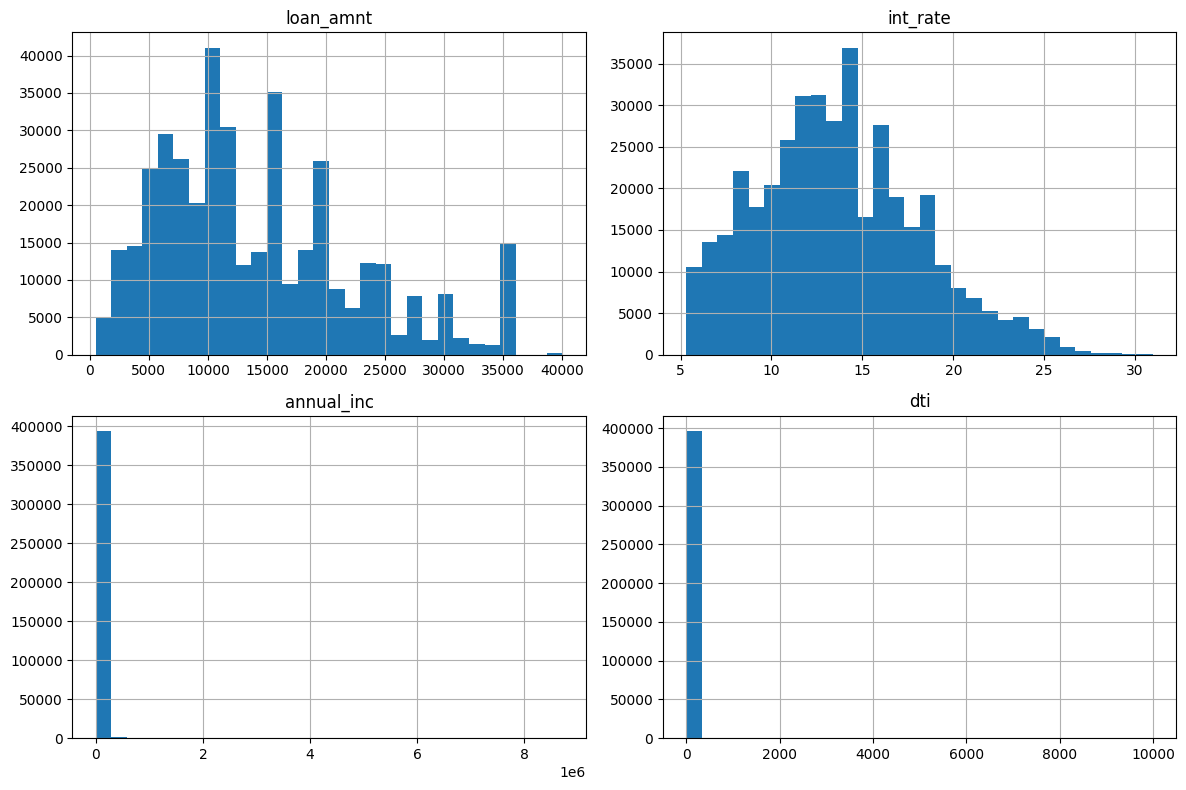

In [13]:
df[['loan_amnt', 'int_rate', 'annual_inc', 'dti']].hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

## Feature Engineering

In [14]:
if 'term' in df.columns:
    df['term_months'] = df['term'].str.extract('(\d+)').astype(int)
    df.drop('term', axis=1, inplace=True)

In [15]:
if 'emp_length' in df.columns:
    df['emp_length'] = df['emp_length'].str.replace('+', '').str.replace('< 1', '0')
    df['emp_length'] = df['emp_length'].str.replace(' years', '').str.replace(' year', '')
    df['emp_length'] = pd.to_numeric(df['emp_length'], errors='coerce').fillna(0)
    print("Cleaned: emp_length")

Cleaned: emp_length


In [16]:
if 'annual_inc' in df.columns and 'loan_amnt' in df.columns:
    df['income_to_loan'] = df['annual_inc'] / (df['loan_amnt'] + 1)
    print("Created: income_to_loan")

Created: income_to_loan


In [17]:
df['total_interest'] = (df['int_rate'] / 100) * df['loan_amnt']
df['loan_to_installment'] = df['loan_amnt'] / (df['installment'] + 1)
df['revol_to_income'] = df['revol_bal'] / (df['annual_inc'] + 1)
print("Created 3 new features")

Created 3 new features


In [18]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

## Model Training & Evaluation

In [19]:
X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train default rate: {y_train.mean():.2%}")

Train: (316824, 25), Test: (79206, 25)
Train default rate: 19.61%


In [20]:
print(y_train.value_counts())
print(f"\nImbalance ratio: {len(y_train[y_train==0]) / len(y_train[y_train==1]):.2f}:1")

default
0    254686
1     62138
Name: count, dtype: int64

Imbalance ratio: 4.10:1


In [21]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

scale_pos_weight: 4.10


In [22]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [23]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(f"Random Forest AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

Random Forest AUC: 0.7030
              precision    recall  f1-score   support

           0       0.81      0.98      0.89     63671
           1       0.52      0.07      0.12     15535

    accuracy                           0.80     79206
   macro avg       0.67      0.53      0.50     79206
weighted avg       0.76      0.80      0.74     79206



In [24]:
xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)
xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [25]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print(f"XGBoost AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))

XGBoost AUC: 0.7193
              precision    recall  f1-score   support

           0       0.89      0.67      0.77     63671
           1       0.33      0.65      0.43     15535

    accuracy                           0.67     79206
   macro avg       0.61      0.66      0.60     79206
weighted avg       0.78      0.67      0.70     79206



In [26]:
lgb = LGBMClassifier(
    n_estimators=100,
    random_state=42,
    verbose=-1,
    class_weight='balanced'
)
lgb.fit(X_train, y_train)

LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)

In [27]:
y_pred_lgb = lgb.predict(X_test)
y_prob_lgb = lgb.predict_proba(X_test)[:, 1]

print(f"LightGBM AUC: {roc_auc_score(y_test, y_prob_lgb):.4f}")
print(classification_report(y_test, y_pred_lgb))

LightGBM AUC: 0.7221
              precision    recall  f1-score   support

           0       0.89      0.66      0.76     63671
           1       0.32      0.67      0.43     15535

    accuracy                           0.66     79206
   macro avg       0.61      0.66      0.60     79206
weighted avg       0.78      0.66      0.69     79206



In [28]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(lgb, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
print(f"CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

CV AUC: 0.7217 (+/- 0.0018)


In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'LightGBM'],
    'AUC': [
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_lgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_lgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_lgb)
    ],
    'F1': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_lgb)
    ]
}).sort_values('AUC', ascending=False)

comparison

,Model,AUC,Precision,Recall,F1
2,LightGBM,0.722112,0.321863,0.668297,0.434475
1,XGBoost,0.719310,0.325705,0.646798,0.433244
0,Random Forest,0.702981,0.521674,0.067396,0.119371


## Model Comparison & Visualization

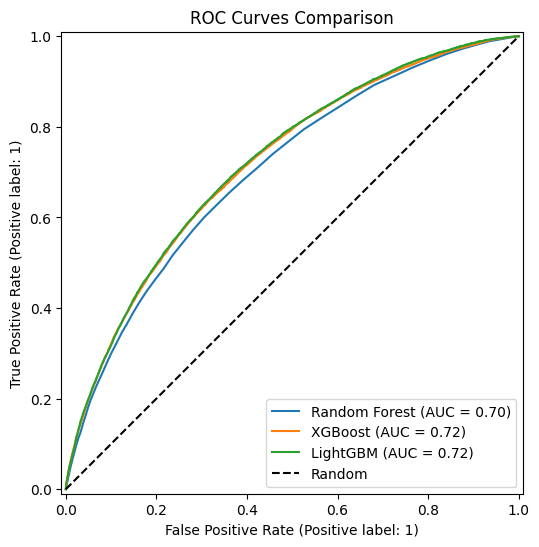

In [30]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(10, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name='Random Forest', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name='XGBoost', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_lgb, name='LightGBM', ax=ax)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.legend()
plt.title('ROC Curves Comparison')
plt.show()

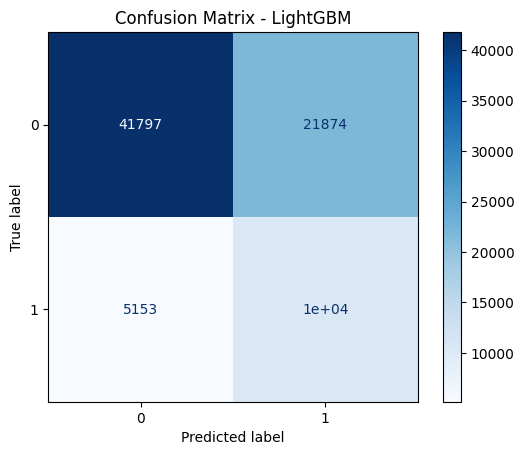

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(lgb, X_test, y_test, cmap='Blues')
plt.title('Confusion Matrix - LightGBM')
plt.show()

In [32]:
best_model = lgb

feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

feat_imp.head(10)

,feature,importance
14,revol_util,247
10,dti,240
21,income_to_loan,217
1,int_rate,212
4,sub_grade,197
7,annual_inc,195
23,loan_to_installment,188
11,open_acc,179
24,revol_to_income,165
13,revol_bal,154


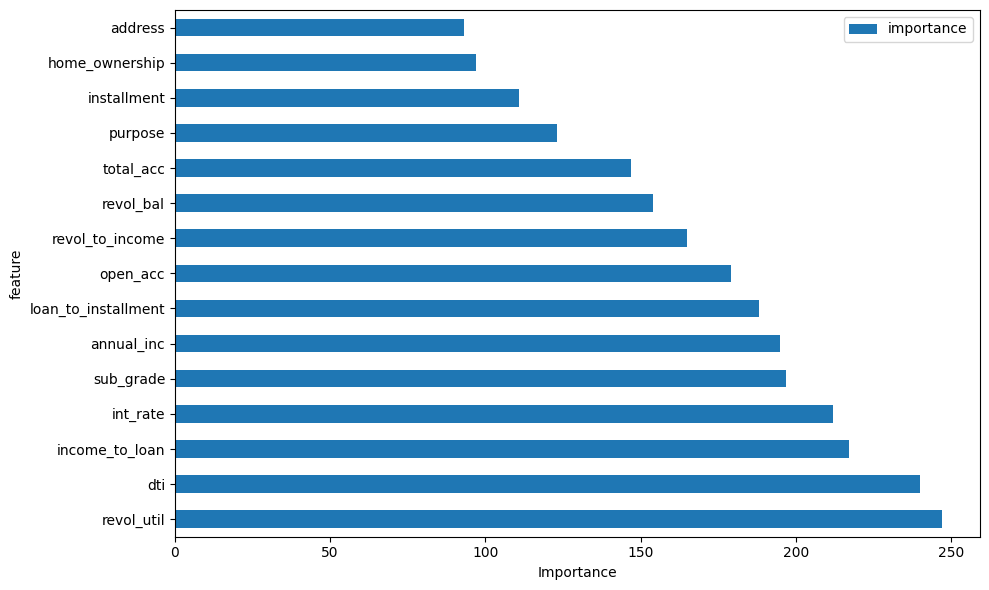

In [33]:
feat_imp.head(15).plot(x='feature', y='importance', kind='barh', figsize=(10,6))
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Saving Best Model

In [34]:
import joblib
import os

os.makedirs('models', exist_ok=True)
joblib.dump(best_model, 'models/best_model.pkl')
joblib.dump(X.columns.tolist(), 'models/feature_names.pkl')

print("Model saved!")

Model saved!


In [35]:
sample = X_test.iloc[0:1]
pred = best_model.predict(sample)
prob = best_model.predict_proba(sample)[0]

print(f"Prediction: {'Default' if pred[0]==1 else 'Paid'}")
print(f"Default probability: {prob[1]:.2%}")

Prediction: Paid
Default probability: 33.41%
